In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import xarray as xr
import matplotlib.patches as mpatches


Loading rainfall response maps...
  File 1 shape: (25, 144)
  File 2 shape: (25, 144)
  File 3 shape: (25, 144)
CO2_ERF_SSP585_minus_SSP245 2.807499999999999
Unnormalized weights: [1.0, 0.3518170426065162, 1.062555066079295]
Sum of unnormalized: 2.414372108685811
Normalized weights: [0.414186361912671, 0.1457178209360681, 0.44009581715126095]
Sum of normalized: 1.0
Weighted average computed
  Result shape: (25, 144)
  Min: -0.6875 mm/day
  Max: 1.6396 mm/day

Plotting...
  vmin: -0.6557, vmax: 0.6557

Figure saved → Rainfall_response_monsoon.png


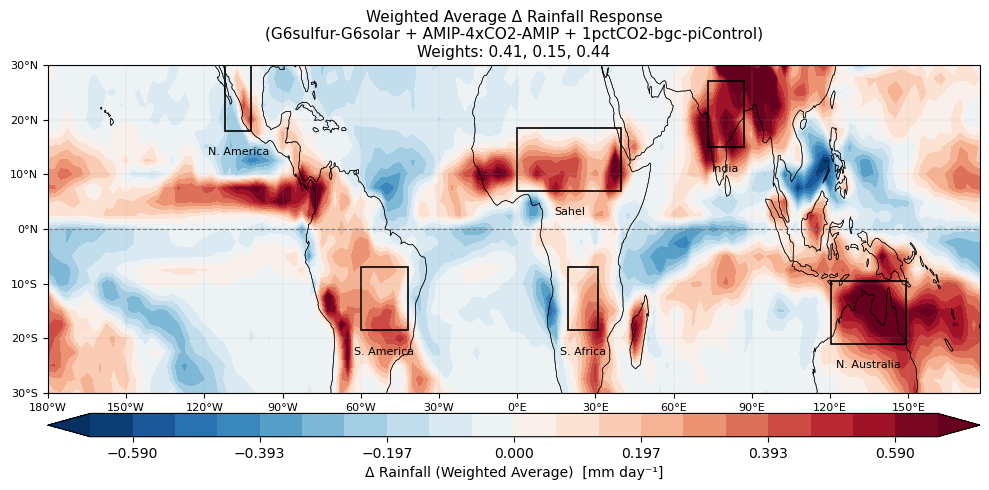


Done!


In [15]:

# ================================================================
# LOAD THE THREE RAINFALL RESPONSE MAPS
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

file_1 = f'{data_path}/Rainfall_response_G6sulfur20212100_minus_G6solar20212100.nc'
file_2 = f'{data_path}/Rainfall_response_amip-4xCO219792013_minus_amip19792013.nc'
file_3 = f'{data_path}/Rainfall_response_1pctCO2-bgcyrs6190_minus_piControlfirst30yrs.nc'


print("Loading rainfall response maps...")
delta_1 = xr.open_dataarray(file_1)
delta_2 = xr.open_dataarray(file_2)
delta_3 = xr.open_dataarray(file_3)

print(f"  File 1 shape: {delta_1.shape}")
print(f"  File 2 shape: {delta_2.shape}")
print(f"  File 3 shape: {delta_3.shape}")

# ================================================================
# COMPUTE WEIGHTED AVERAGE
# ================================================================

# Radiative Weights

CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0 # From Table AIII.4e | Effective radiative forcing (W m–2) time series of all climate forcers for SSP5-8.5.
CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0 # From Table AIII.4c | Effective radiative forcing (W m–2) time series of all climate forcers for SSP2-4.5.

CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

print('CO2_ERF_SSP585_minus_SSP245', CO2_ERF_SSP585_minus_SSP245)


# Concetration Weights
CO2_conc_SSP585_yr2100 = 1135 #ppm 
                            # from Table AIII.2 | Future abundances of CO2, CH4 and N2O for selected SSP scenarios (2020–2500).
                            # https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_AnnexIII.pdf
CO2_conc_SSP245_yr2100 = 603 #ppm
CO2_conc_ratio_SSP585_to_SSP245= 1135/603
CO2_conc_ratio_pctCO2bgc_to_piCtrl= 2 # since I selected yrs 61-90 from the bgc run which have double the concentration of CO2 wrt piControl


StratHeatWeight=CO2_ERF_SSP585_minus_SSP245/CO2_ERF_SSP585_minus_SSP245
CO2effectWeight=CO2_ERF_SSP585_minus_SSP245/7.98 # 7.98 W/m2 is the ERF of 4CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# Before
# PlantPhysWeight=CO2_ERF_SSP585_minus_SSP245/3.8 # 3.8 W/m2 is the ERF of 2CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# After meeting with Chris and Anupama
PlantPhysWeight = CO2_conc_ratio_pctCO2bgc_to_piCtrl/CO2_conc_ratio_SSP585_to_SSP245

# Normalize to sum to 1
weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
total_weight = sum(weights_unnormalized)
weights = [w / total_weight for w in weights_unnormalized]

print(f"Unnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight}")
print(f"Normalized weights: {weights}")
print(f"Sum of normalized: {sum(weights)}")

# Extract values and compute weighted average
delta_weighted = (
    weights[0] * delta_1.values + 
    weights[1] * delta_2.values + 
    weights[2] * delta_3.values
)

# Convert back to DataArray with same coordinates as delta_1
delta_avg = xr.DataArray(
    delta_weighted,
    coords={'lat': delta_1.lat, 'lon': delta_1.lon},
    dims=['lat', 'lon'],
    name='weighted_rainfall_response'
)

print(f"Weighted average computed")
print(f"  Result shape: {delta_avg.shape}")
print(f"  Min: {delta_avg.min().values:.4f} mm/day")
print(f"  Max: {delta_avg.max().values:.4f} mm/day")

# ================================================================
# PLOTTING 
# ================================================================

lat = delta_avg.lat.values
lon = delta_avg.lon.values
data = delta_avg.values
LON, LAT = np.meshgrid(lon, lat)

# Colorbar range (98th percentile)
vmax = float(np.nanpercentile(np.abs(data), 98))
vmin = -vmax
levels = np.linspace(-vmax, vmax, 21)

print(f"\nPlotting...")
print(f"  vmin: {vmin:.4f}, vmax: {vmax:.4f}")

fig, ax = plt.subplots(figsize=(10, 5),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# Add coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
ax.set_global()

# Contour plot
im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                 extend='both', transform=ccrs.PlateCarree())

# Coastlines (detailed)
try:
    shpfilename = shpreader.natural_earth(
        resolution="110m", category="physical", name="coastline"
    )
    reader = shpreader.Reader(shpfilename)
    for geom in reader.geometries():
        if hasattr(geom, "geoms"):
            for g in geom.geoms:
                ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
        else:
            ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
except Exception as e:
    print(f"  Warning: Could not load detailed coastlines: {e}")

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                    pad=0.05, shrink=1.0, aspect=40)
cbar.set_label(f"Δ Rainfall (Weighted Average)  [mm day⁻¹]", fontsize=10)

# Equator line
ax.plot([float(lon.min()), float(lon.max())], [0, 0],
        color='gray', linewidth=0.8, linestyle='--',
        transform=ccrs.PlateCarree())

# Set extent and aspect
ax.set_extent([float(lon.min()), float(lon.max()),
               float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
ax.set_aspect('auto')

# Set ticks
ax.set_xticks(np.arange(np.floor(float(lon.min())),
                        np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(np.floor(float(lat.min())),
                        np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
ax.tick_params(labelsize=8)

# Custom lat/lon labels
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))

# Title
ax.set_title(
    f"Weighted Average Δ Rainfall Response\n"
    f"(G6sulfur-G6solar + AMIP-4xCO2-AMIP + 1pctCO2-bgc-piControl)\n"
    f"Weights: {weights[0]:.2f}, {weights[1]:.2f}, {weights[2]:.2f}",
    fontsize=11
)
ax.grid(True, linewidth=0.3, alpha=0.4)

# ================================================================
# BOMBARDI AND BOOS 2021 MONSOON REGIONS
# ================================================================

regions = {
    'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
    'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),   'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
}

for name, coords in regions.items():
    lon0, lon1 = coords['lon']
    lat0, lat1 = coords['lat']
    rect = mpatches.Rectangle(
        (lon0, lat0), lon1-lon0, lat1-lat0,
        linewidth=1.2, edgecolor='black', facecolor='none',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)
    ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
            fontsize=8, ha='center', va='top',
            transform=ccrs.PlateCarree())

plt.tight_layout()
plt.savefig('Rainfall_response_monsoon.png',
            dpi=150, bbox_inches="tight")
print(f"\nFigure saved → Rainfall_response_monsoon.png")
plt.show()

# ================================================================
# SAVE THE WEIGHTED AVERAGE
# ================================================================

# output_file = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Rainfall_response_weighted_average.nc'
# delta_avg.to_netcdf(output_file)
# print(f"Weighted average saved → {output_file}")

print("\nDone!")

# proper plotting with weights calculated only once

In [3]:
# ================================================================
# COMPUTE WEIGHTED AVERAGE
# ================================================================

# Weights

CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0 # From Table AIII.4e | Effective radiative forcing (W m–2) time series of all climate forcers for SSP5-8.5.
CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0 # From Table AIII.4c | Effective radiative forcing (W m–2) time series of all climate forcers for SSP2-4.5.

CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245
print('CO2_ERF_SSP585_minus_SSP245', CO2_ERF_SSP585_minus_SSP245)

# Concetration Weights
CO2_conc_SSP585_yr2100 = 1135 #ppm 
                            # from Table AIII.2 | Future abundances of CO2, CH4 and N2O for selected SSP scenarios (2020–2500).
                            # https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_AnnexIII.pdf
CO2_conc_SSP245_yr2100 = 603 #ppm
CO2_conc_ratio_SSP585_to_SSP245= 1135/603
CO2_conc_ratio_pctCO2bgc_to_piCtrl= 2 # since I selected yrs 61-90 from the bgc run which have double the concentration of CO2 wrt piControl

StratHeatWeight=CO2_ERF_SSP585_minus_SSP245/CO2_ERF_SSP585_minus_SSP245
CO2effectWeight=CO2_ERF_SSP585_minus_SSP245/7.98 # 7.98 W/m2 is the ERF of 4CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# Before
# PlantPhysWeight=CO2_ERF_SSP585_minus_SSP245/3.8 # 3.8 W/m2 is the ERF of 2CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# After meeting with Chris and Anupama
PlantPhysWeight = CO2_conc_ratio_pctCO2bgc_to_piCtrl/CO2_conc_ratio_SSP585_to_SSP245

# Normalize to sum to 1
weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
total_weight = sum(weights_unnormalized)
weights = [w / total_weight for w in weights_unnormalized]

print(f"Unnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight}")
print(f"Normalized weights: {weights}")
print(f"Sum of normalized: {sum(weights)}")

StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights
print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")

CO2_ERF_SSP585_minus_SSP245 2.807499999999999
Unnormalized weights: [1.0, 0.3518170426065162, 1.062555066079295]
Sum of unnormalized: 2.414372108685811
Normalized weights: [0.414186361912671, 0.1457178209360681, 0.44009581715126095]
Sum of normalized: 1.0
Normalized weights: StratHeat=0.414, CO2effect=0.146, PlantPhys=0.440


In [4]:
data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

File_Total_rainfall_response = f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_all_seasons.nc'
File_Stratospheric_warming_component = f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_all_seasons.nc'
File_Direct_CO2effect_component = f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_all_seasons.nc'
File_Plant_physiology_component = f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_all_seasons.nc'

print("Loading rainfall response maps...")
Total_rainfall_response = xr.open_dataset(File_Total_rainfall_response)
Stratospheric_warming_component = xr.open_dataset(File_Stratospheric_warming_component)
Direct_CO2effect_component = xr.open_dataset(File_Direct_CO2effect_component)
Plant_physiology_component = xr.open_dataset(File_Plant_physiology_component)

print(f"  File Total_rainfall_response shape: {Total_rainfall_response}")
print(f"  File Stratospheric_warming_component shape: {Stratospheric_warming_component}")
print(f"  File Direct_CO2effect_component shape: {Direct_CO2effect_component}")
print(f"  File Plant_physiology_component shape: {Plant_physiology_component}")

Loading rainfall response maps...
  File Total_rainfall_response shape: <xarray.Dataset> Size: 45kB
Dimensions:  (lat: 25, lon: 144)
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
Data variables:
    SUM      (lat, lon) float32 14kB ...
    WIN      (lat, lon) float32 14kB ...
    ANN      (lat, lon) float32 14kB ...
  File Stratospheric_warming_component shape: <xarray.Dataset> Size: 45kB
Dimensions:  (lat: 25, lon: 144)
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
Data variables:
    SUM      (lat, lon) float32 14kB ...
    WIN      (lat, lon) float32 14kB ...
    ANN      (lat, lon) float32 14kB ...
  File Direct_CO2effect_component shape: <xarray.Dataset> Size: 45kB
Dimensions:  (lat: 25, lon: 144)
Coordinates:
  * lat      (lat) 

In [5]:
seasons = ['ANN', 'SUM', 'WIN']

Loading rainfall response maps...

Unnormalized weights: [1.0, 0.3518170426065162, 1.062555066079295]
Sum of unnormalized: 2.414372
Normalized weights: StratHeat=0.414, CO2effect=0.146, PlantPhys=0.440
Sum of normalized: 1.000000
Figure saved → Rainfall_response_3x2_total_vs_reconstructed.png


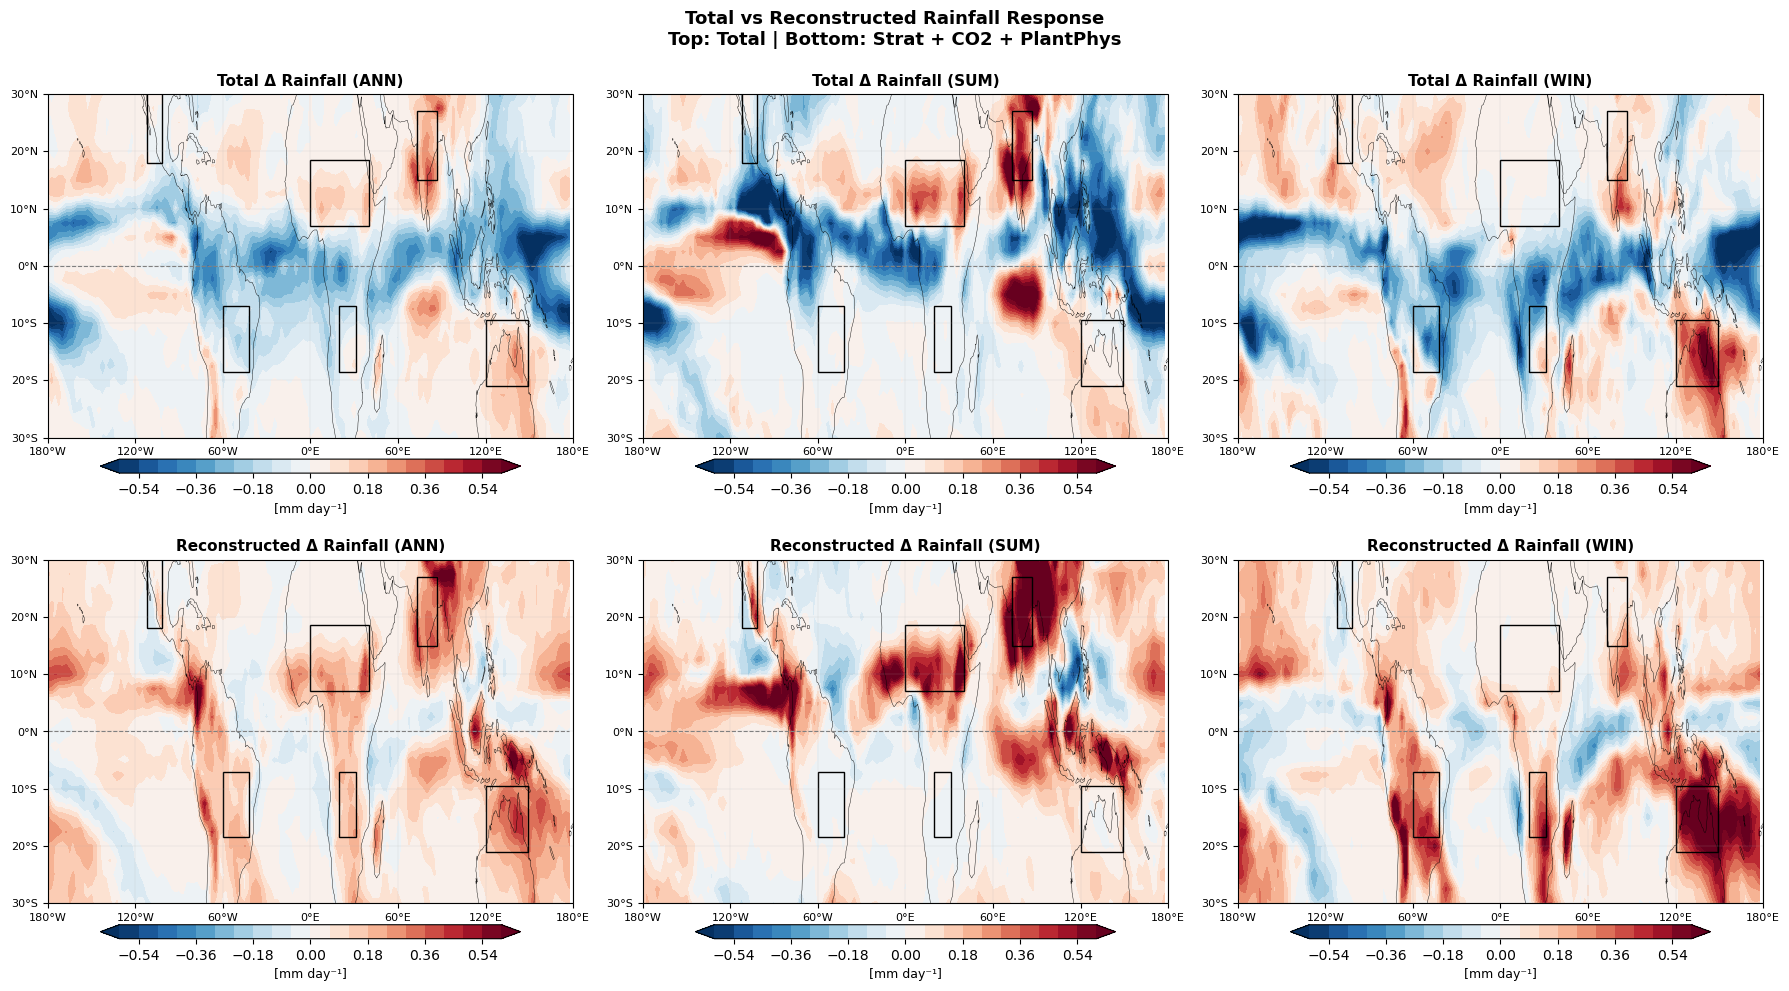

Done!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import xarray as xr
import matplotlib.patches as mpatches

# ================================================================
# LOAD DATA
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

print("Loading rainfall response maps...")
Total_rainfall_response = xr.open_dataset(f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_all_seasons.nc')
Stratospheric_warming = xr.open_dataset(f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_all_seasons.nc')
Direct_CO2effect = xr.open_dataset(f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_all_seasons.nc')
Plant_physiology = xr.open_dataset(f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_all_seasons.nc')

# # ================================================================
# # COMPUTE WEIGHTED AVERAGE
# # ================================================================
# # # Weights based on Effective Radiative Forcing (ERF)
# # CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0  # From Table AIII.4e | ERF time series for SSP5-8.5
# # CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0  # From Table AIII.4c | ERF time series for SSP2-4.5
# # CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

# # print(f'CO2_ERF_SSP585: {CO2_ERF_SSP585:.3f} W/m²')
# # print(f'CO2_ERF_SSP245: {CO2_ERF_SSP245:.3f} W/m²')
# # print(f'CO2_ERF_SSP585_minus_SSP245: {CO2_ERF_SSP585_minus_SSP245:.3f} W/m²')

# # StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
# # CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98  # 4CO2 ERF from Knutti et al. 2020
# # PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8   # 2CO2 ERF from Knutti et al. 2020

# # Weights

# CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0 # From Table AIII.4e | Effective radiative forcing (W m–2) time series of all climate forcers for SSP5-8.5.
# CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0 # From Table AIII.4c | Effective radiative forcing (W m–2) time series of all climate forcers for SSP2-4.5.

# CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245
# print('CO2_ERF_SSP585_minus_SSP245', CO2_ERF_SSP585_minus_SSP245)

# # Concetration Weights
# CO2_conc_SSP585_yr2100 = 1135 #ppm 
#                             # from Table AIII.2 | Future abundances of CO2, CH4 and N2O for selected SSP scenarios (2020–2500).
#                             # https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_AnnexIII.pdf
# CO2_conc_SSP245_yr2100 = 603 #ppm
# CO2_conc_ratio_SSP585_to_SSP245= 1135/603
# CO2_conc_ratio_pctCO2bgc_to_piCtrl= 2 # since I selected yrs 61-90 from the bgc run which have double the concentration of CO2 wrt piControl

# StratHeatWeight=CO2_ERF_SSP585_minus_SSP245/CO2_ERF_SSP585_minus_SSP245
# CO2effectWeight=CO2_ERF_SSP585_minus_SSP245/7.98 # 7.98 W/m2 is the ERF of 4CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# # Before
# # PlantPhysWeight=CO2_ERF_SSP585_minus_SSP245/3.8 # 3.8 W/m2 is the ERF of 2CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# # After meeting with Chris and Anupama
# PlantPhysWeight = CO2_conc_ratio_pctCO2bgc_to_piCtrl/CO2_conc_ratio_SSP585_to_SSP245

# # Normalize to sum to 1
# weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
# total_weight = sum(weights_unnormalized)
# weights = [w / total_weight for w in weights_unnormalized]

# StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

print(f"\nUnnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight:.6f}")
print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")
print(f"Sum of normalized: {sum(weights):.6f}")

# Compute reconstructed response for all seasons
Reconstructed_response = xr.Dataset()
for season in ['ANN', 'SUM', 'WIN']:
    Reconstructed_response[season] = (
        StratHeatWeight * Stratospheric_warming[season] +
        CO2effectWeight * Direct_CO2effect[season] +
        PlantPhysWeight * Plant_physiology[season]
    )

# ================================================================
# PLOTTING - 3x2 SUBPLOTS
# ================================================================

s = ['ANN', 'SUM', 'WIN']
titles_total = [f'Total Δ Rainfall ({s})', f'Total Δ Rainfall ({s})', f'Total Δ Rainfall ({s})']
titles_recon = [f'Reconstructed Δ Rainfall ({s})', f'Reconstructed Δ Rainfall ({s})', f'Reconstructed Δ Rainfall ({s})']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), 
                         subplot_kw={"projection": ccrs.PlateCarree()})

# Monsoon regions (Bombardi and Boos 2021)
regions = {
    'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
    'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),   'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
}

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Plot Total response (top row)
for idx, season in enumerate(seasons):
    ax = axes[0, idx]
    data = Total_rainfall_response[season].values
    lat = Total_rainfall_response.lat.values
    lon = Total_rainfall_response.lon.values
    LON, LAT = np.meshgrid(lon, lat)
    
    # Colorbar range
    vmax = 0.6 #float(np.nanpercentile(np.abs(data), 98))
    vmin = -vmax
    levels = np.linspace(-vmax, vmax, 21)
    
    # Plot
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.set_global()
    
    im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())
    
    # Equator line
    ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
    ax.set_extent([float(lon.min()), float(lon.max()),
                   float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-30, 31, 10), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=8)
    
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
    
    ax.set_title(f'Total Δ Rainfall ({season})', fontsize=11, fontweight='bold')
    ax.grid(True, linewidth=0.3, alpha=0.4)
    
    # Add monsoon boxes
    for name, coords in regions.items():
        lon0, lon1 = coords['lon']
        lat0, lat1 = coords['lat']
        rect = mpatches.Rectangle(
            (lon0, lat0), lon1-lon0, lat1-lat0,
            linewidth=1.0, edgecolor='black', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8, aspect=30)
    cbar.set_label('[mm day⁻¹]', fontsize=9)

# Plot Reconstructed response (bottom row)
for idx, season in enumerate(seasons):
    ax = axes[1, idx]
    data = Reconstructed_response[season].values
    lat = Reconstructed_response[season].lat.values
    lon = Reconstructed_response[season].lon.values
    LON, LAT = np.meshgrid(lon, lat)
    
    # Colorbar range
    vmax = 0.6 #float(np.nanpercentile(np.abs(data), 98))
    vmin = -vmax
    levels = np.linspace(-vmax, vmax, 21)
    
    # Plot
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.set_global()
    
    im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())
    
    # Equator line
    ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
    ax.set_extent([float(lon.min()), float(lon.max()),
                   float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-30, 31, 10), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=8)
    
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
    
    ax.set_title(f'Reconstructed Δ Rainfall ({season})', fontsize=11, fontweight='bold')
    ax.grid(True, linewidth=0.3, alpha=0.4)
    
    # Add monsoon boxes
    for name, coords in regions.items():
        lon0, lon1 = coords['lon']
        lat0, lat1 = coords['lat']
        rect = mpatches.Rectangle(
            (lon0, lat0), lon1-lon0, lat1-lat0,
            linewidth=1.0, edgecolor='black', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8, aspect=30)
    cbar.set_label('[mm day⁻¹]', fontsize=9)

plt.suptitle('Total vs Reconstructed Rainfall Response\nTop: Total | Bottom: Strat + CO2 + PlantPhys', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('Rainfall_response_3x2_total_vs_reconstructed.png', dpi=150, bbox_inches="tight")
print("Figure saved → Rainfall_response_3x2_total_vs_reconstructed.png")
plt.show()

print("Done!")

Loading rainfall response maps...

Unnormalized weights: [1.0, 0.3518170426065162, 1.062555066079295]
Sum of unnormalized: 2.414372
Normalized weights: StratHeat=0.414, CO2effect=0.146, PlantPhys=0.440
Sum of normalized: 1.000000
Figure saved → Rainfall_response_6x3_monsoon_components.png


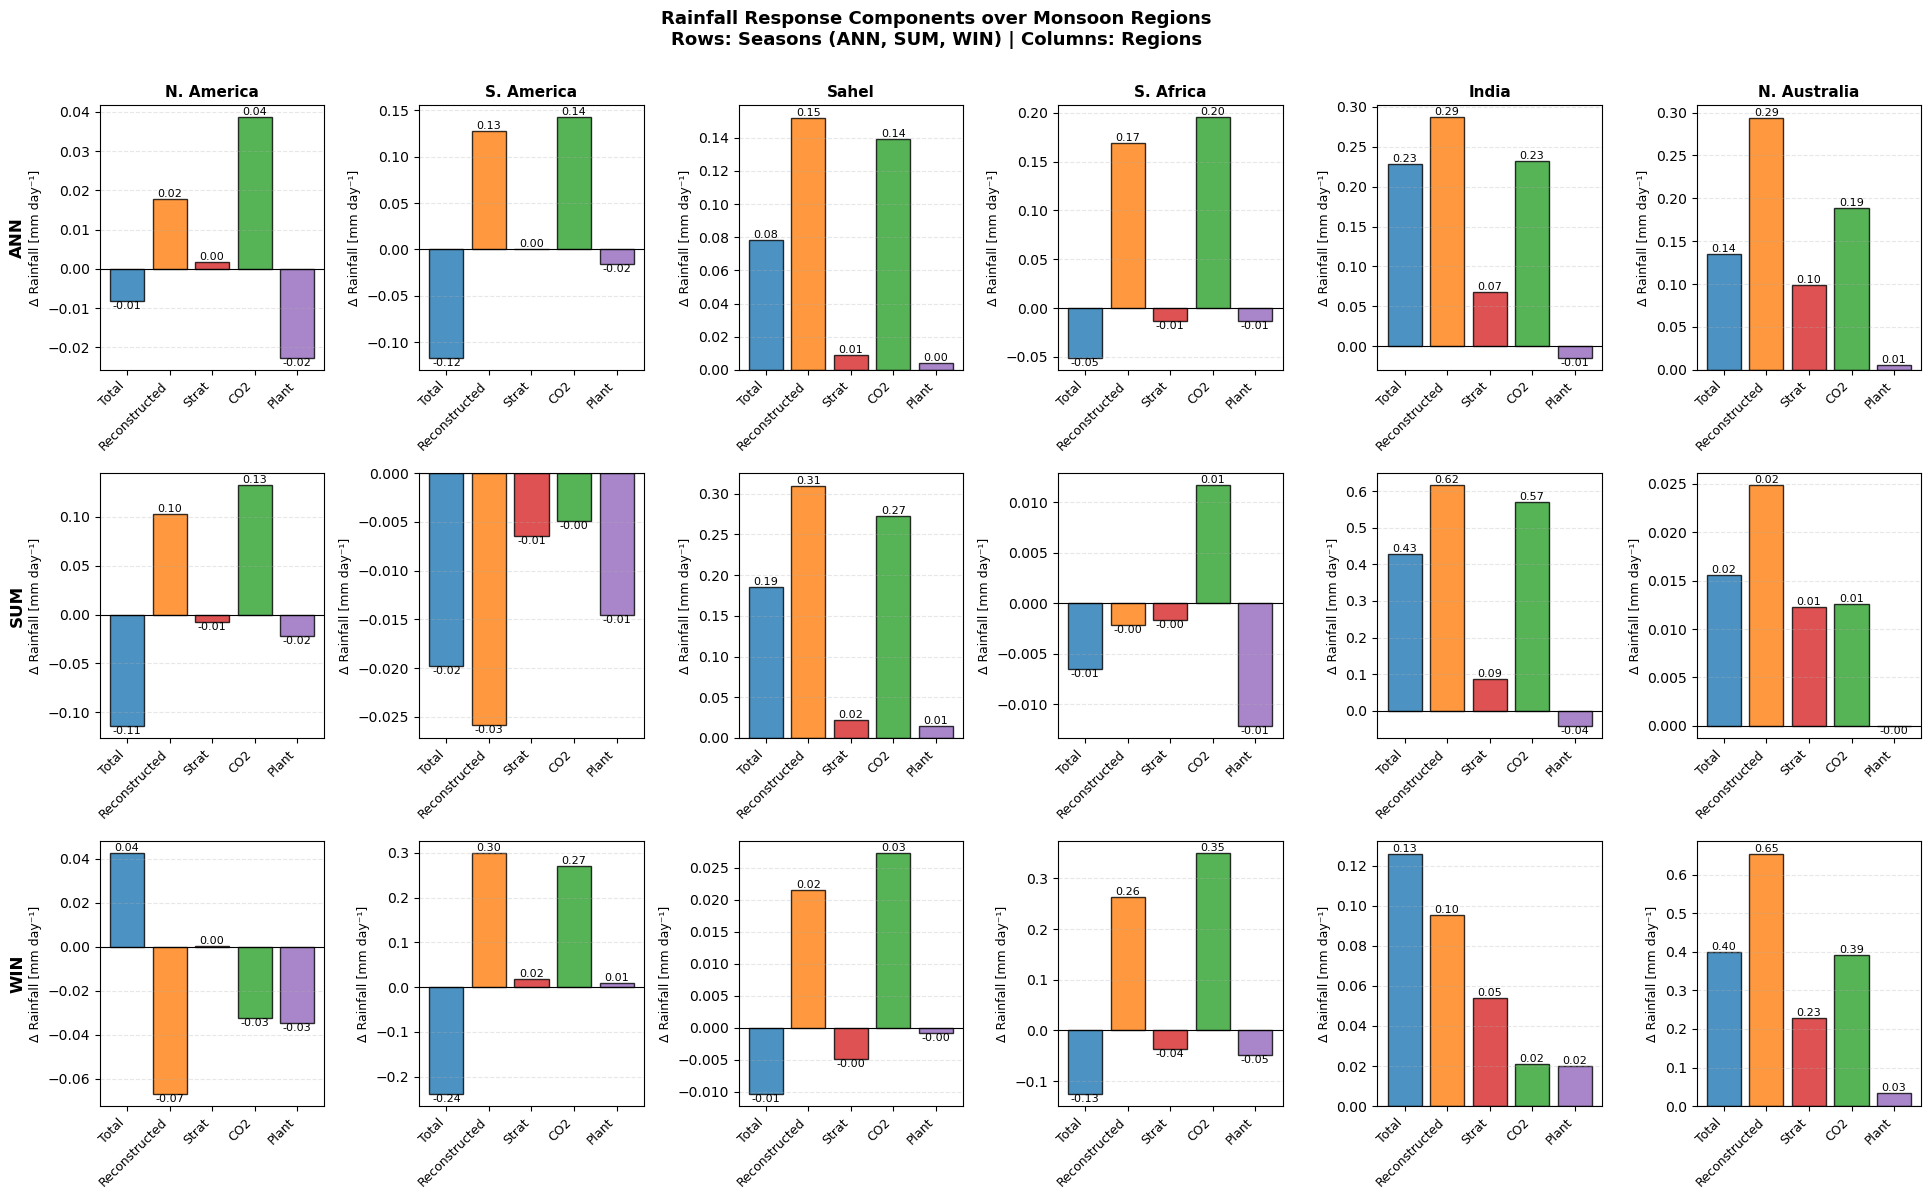

Done!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ================================================================
# LOAD DATA
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

print("Loading rainfall response maps...")
Total_rainfall_response = xr.open_dataset(f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_all_seasons.nc')
Stratospheric_warming = xr.open_dataset(f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_all_seasons.nc')
Direct_CO2effect = xr.open_dataset(f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_all_seasons.nc')
Plant_physiology = xr.open_dataset(f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_all_seasons.nc')

# # ================================================================
# # COMPUTE WEIGHTED AVERAGE
# # ================================================================
# # # Weights based on Effective Radiative Forcing (ERF)
# # CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0  # From Table AIII.4e | ERF time series for SSP5-8.5
# # CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0  # From Table AIII.4c | ERF time series for SSP2-4.5
# # CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

# # print(f'CO2_ERF_SSP585: {CO2_ERF_SSP585:.3f} W/m²')
# # print(f'CO2_ERF_SSP245: {CO2_ERF_SSP245:.3f} W/m²')
# # print(f'CO2_ERF_SSP585_minus_SSP245: {CO2_ERF_SSP585_minus_SSP245:.3f} W/m²')

# # StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
# # CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98  # 4CO2 ERF from Knutti et al. 2020
# # PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8   # 2CO2 ERF from Knutti et al. 2020

# # Weights

# CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0 # From Table AIII.4e | Effective radiative forcing (W m–2) time series of all climate forcers for SSP5-8.5.
# CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0 # From Table AIII.4c | Effective radiative forcing (W m–2) time series of all climate forcers for SSP2-4.5.

# CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245
# print('CO2_ERF_SSP585_minus_SSP245', CO2_ERF_SSP585_minus_SSP245)

# # Concetration Weights
# CO2_conc_SSP585_yr2100 = 1135 #ppm 
#                             # from Table AIII.2 | Future abundances of CO2, CH4 and N2O for selected SSP scenarios (2020–2500).
#                             # https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_AnnexIII.pdf
# CO2_conc_SSP245_yr2100 = 603 #ppm
# CO2_conc_ratio_SSP585_to_SSP245= 1135/603
# CO2_conc_ratio_pctCO2bgc_to_piCtrl= 2 # since I selected yrs 61-90 from the bgc run which have double the concentration of CO2 wrt piControl

# StratHeatWeight=CO2_ERF_SSP585_minus_SSP245/CO2_ERF_SSP585_minus_SSP245
# CO2effectWeight=CO2_ERF_SSP585_minus_SSP245/7.98 # 7.98 W/m2 is the ERF of 4CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# # Before
# # PlantPhysWeight=CO2_ERF_SSP585_minus_SSP245/3.8 # 3.8 W/m2 is the ERF of 2CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# # After meeting with Chris and Anupama
# PlantPhysWeight = CO2_conc_ratio_pctCO2bgc_to_piCtrl/CO2_conc_ratio_SSP585_to_SSP245

print(f"\nUnnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight:.6f}")
print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")
print(f"Sum of normalized: {sum(weights):.6f}")

# ================================================================
# MONSOON REGIONS (Bombardi and Boos 2021)
# ================================================================

regions = {
    # 'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
    # 'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
    'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
    'S. America':   {'lon': (-60, -42),    'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),   'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
}

# ================================================================
# EXTRACT REGIONAL MEANS
# ================================================================

def extract_regional_mean(ds, region_coords):
    """Extract spatial mean over a region."""
    lon0, lon1 = region_coords['lon']
    lat0, lat1 = region_coords['lat']
    
    # Handle lon wrapping if needed
    if lon0 > lon1:
        region = ds.sel(lon=slice(lon0, 360)) + ds.sel(lon=slice(0, lon1))
    else:
        region = ds.sel(lon=slice(lon0, lon1), lat=slice(lat0, lat1))
    
    return region.mean(dim=['lat', 'lon'])

# Extract means for all regions and seasons
regional_data = {}

for region_name, region_coords in regions.items():
    regional_data[region_name] = {}
    
    for season in ['ANN', 'SUM', 'WIN']:
        regional_data[region_name][season] = {
            'Total': float(extract_regional_mean(Total_rainfall_response[[season]], region_coords)[season].values),
            'Strat_weighted': StratHeatWeight * float(extract_regional_mean(Stratospheric_warming[[season]], region_coords)[season].values),
            'CO2_weighted': CO2effectWeight * float(extract_regional_mean(Direct_CO2effect[[season]], region_coords)[season].values),
            'Plant_weighted': PlantPhysWeight * float(extract_regional_mean(Plant_physiology[[season]], region_coords)[season].values),
        }
    
    # Compute reconstructed as sum of weighted components
    for season in ['ANN', 'SUM', 'WIN']:
        regional_data[region_name][season]['Reconstructed'] = (
            regional_data[region_name][season]['Strat_weighted'] +
            regional_data[region_name][season]['CO2_weighted'] +
            regional_data[region_name][season]['Plant_weighted']
        )

# ================================================================
# PLOTTING - 6x3 BAR PLOTS
# ================================================================

region_names = list(regions.keys())
seasons = ['ANN', 'SUM', 'WIN']

fig, axes = plt.subplots(3, 6, figsize=(20, 12))

bar_labels = ['Total', 'Reconstructed', 'Strat', 'CO2', 'Plant']
bar_colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd']

for season_idx, season in enumerate(seasons):
    for region_idx, region_name in enumerate(region_names):
        ax = axes[season_idx, region_idx]
        
        # Get values for this region and season
        values = [
            regional_data[region_name][season]['Total'],
            regional_data[region_name][season]['Reconstructed'],
            regional_data[region_name][season]['Strat_weighted'],
            regional_data[region_name][season]['CO2_weighted'],
            regional_data[region_name][season]['Plant_weighted'],
        ]
        
        # Create bar plot
        x_pos = np.arange(len(bar_labels))
        bars = ax.bar(x_pos, values, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
        
        # Add horizontal line at y=0
        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
        
        # Formatting
        ax.set_xticks(x_pos)
        ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Δ Rainfall [mm day⁻¹]', fontsize=9)
        ax.grid(True, axis='y', alpha=0.3, linestyle='--')
        
        # Title: Region name for first row, Season on the right side
        if season_idx == 0:
            ax.set_title(region_name, fontsize=11, fontweight='bold')
        
        # Add season label on y-axis label position
        if region_idx == 0:
            ax.text(-0.4, 0.5, season, transform=ax.transAxes, 
                   fontsize=12, fontweight='bold', va='center', rotation=90)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2f}',
                   ha='center', va='bottom' if height > 0 else 'top', 
                   fontsize=8)

plt.suptitle('Rainfall Response Components over Monsoon Regions\nRows: Seasons (ANN, SUM, WIN) | Columns: Regions', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0.03, 0, 1, 0.99])
plt.savefig('Rainfall_response_6x3_monsoon_components.png', dpi=150, bbox_inches="tight")
print("Figure saved → Rainfall_response_6x3_monsoon_components.png")
plt.show()

print("Done!")

# Monsoon

In [8]:
data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

File_Total_rainfall_response = f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_monsoon.nc'
File_Stratospheric_warming_component = f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_monsoon.nc'
File_Direct_CO2effect_component = f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_monsoon.nc'
File_Plant_physiology_component = f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_monsoon.nc'

print("Loading rainfall response maps...")
Total_rainfall_response = xr.open_dataarray(File_Total_rainfall_response)
Stratospheric_warming_component = xr.open_dataarray(File_Stratospheric_warming_component)
Direct_CO2effect_component = xr.open_dataarray(File_Direct_CO2effect_component)
Plant_physiology_component = xr.open_dataarray(File_Plant_physiology_component)

print(f"  File Total_rainfall_response shape: {Total_rainfall_response}")
print(f"  File Stratospheric_warming_component shape: {Stratospheric_warming_component}")
print(f"  File Direct_CO2effect_component shape: {Direct_CO2effect_component}")
print(f"  File Plant_physiology_component shape: {Plant_physiology_component}")

Loading rainfall response maps...
  File Total_rainfall_response shape: <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  File Stratospheric_warming_component shape: <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  File Direct_CO2effect_component shape: <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  File Plant_physiology_component shape: <xarray.DataArray (lat: 25, l

Loading monsoon rainfall response maps...
  Total shape: (25, 144)
  Strat shape: (25, 144)

Unnormalized weights: [1.0, 0.3518170426065162, 1.062555066079295]
Sum of unnormalized: 2.414372
Normalized weights: StratHeat=0.414, CO2effect=0.146, PlantPhys=0.440
Sum of normalized: 1.000000
N. America
S. America
Sahel
S. Africa
India
N. Australia
N. America
S. America
Sahel
S. Africa
India
N. Australia

Figure saved → Monsoon_rainfall_response_1x2_maps.png


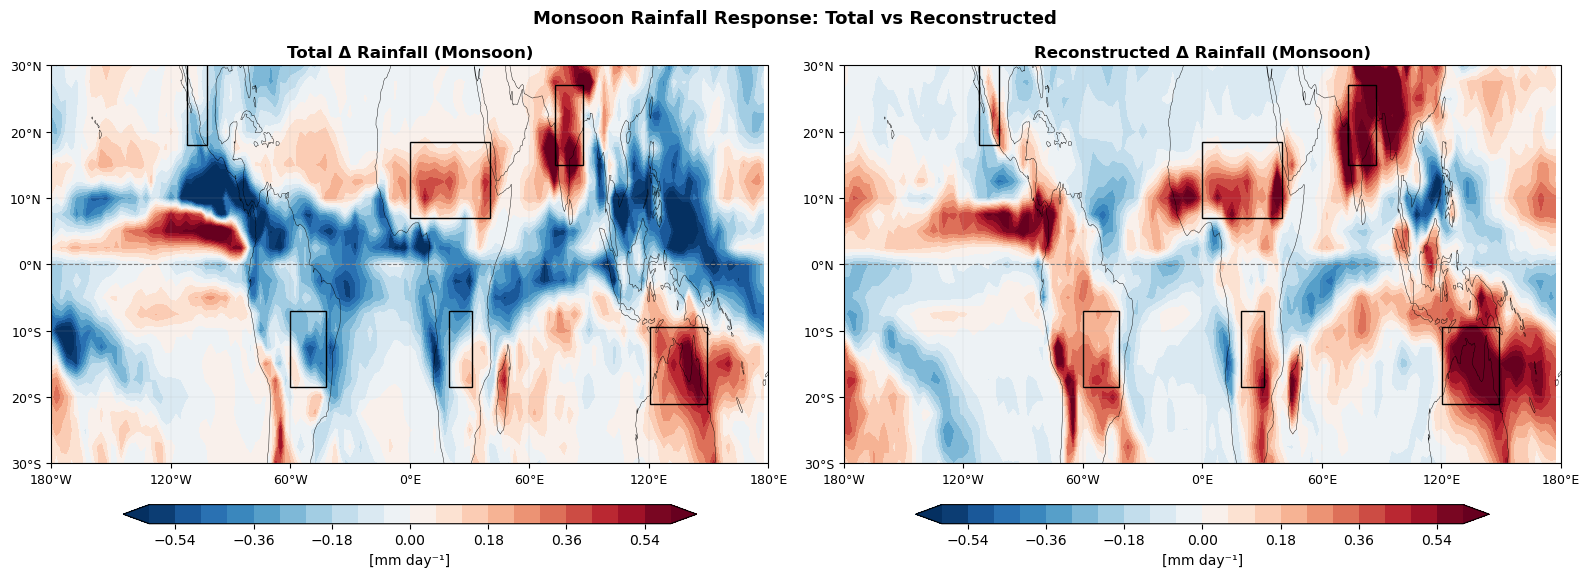

Done!


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import matplotlib.patches as mpatches

# ================================================================
# LOAD DATA (MONSOON ONLY)
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

print("Loading monsoon rainfall response maps...")
Total_rainfall_response = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_monsoon.nc')
Stratospheric_warming = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_monsoon.nc')
Direct_CO2effect = xr.open_dataarray(f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_monsoon.nc')
Plant_physiology = xr.open_dataarray(f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_monsoon.nc')

print(f"  Total shape: {Total_rainfall_response.shape}")
print(f"  Strat shape: {Stratospheric_warming.shape}")

# # ================================================================
# # COMPUTE WEIGHTED AVERAGE
# # ================================================================
# # # Weights based on Effective Radiative Forcing (ERF)
# # CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0  # From Table AIII.4e | ERF time series for SSP5-8.5
# # CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0  # From Table AIII.4c | ERF time series for SSP2-4.5
# # CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

# # print(f'CO2_ERF_SSP585: {CO2_ERF_SSP585:.3f} W/m²')
# # print(f'CO2_ERF_SSP245: {CO2_ERF_SSP245:.3f} W/m²')
# # print(f'CO2_ERF_SSP585_minus_SSP245: {CO2_ERF_SSP585_minus_SSP245:.3f} W/m²')

# # StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
# # CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98  # 4CO2 ERF from Knutti et al. 2020
# # PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8   # 2CO2 ERF from Knutti et al. 2020

# # Weights

# CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0 # From Table AIII.4e | Effective radiative forcing (W m–2) time series of all climate forcers for SSP5-8.5.
# CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0 # From Table AIII.4c | Effective radiative forcing (W m–2) time series of all climate forcers for SSP2-4.5.

# CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245
# print('CO2_ERF_SSP585_minus_SSP245', CO2_ERF_SSP585_minus_SSP245)

# # Concetration Weights
# CO2_conc_SSP585_yr2100 = 1135 #ppm 
#                             # from Table AIII.2 | Future abundances of CO2, CH4 and N2O for selected SSP scenarios (2020–2500).
#                             # https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_AnnexIII.pdf
# CO2_conc_SSP245_yr2100 = 603 #ppm
# CO2_conc_ratio_SSP585_to_SSP245= 1135/603
# CO2_conc_ratio_pctCO2bgc_to_piCtrl= 2 # since I selected yrs 61-90 from the bgc run which have double the concentration of CO2 wrt piControl

# StratHeatWeight=CO2_ERF_SSP585_minus_SSP245/CO2_ERF_SSP585_minus_SSP245
# CO2effectWeight=CO2_ERF_SSP585_minus_SSP245/7.98 # 7.98 W/m2 is the ERF of 4CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# # Before
# # PlantPhysWeight=CO2_ERF_SSP585_minus_SSP245/3.8 # 3.8 W/m2 is the ERF of 2CO2 taken from https://acp.copernicus.org/articles/20/9591/2020/
# # After meeting with Chris and Anupama
# PlantPhysWeight = CO2_conc_ratio_pctCO2bgc_to_piCtrl/CO2_conc_ratio_SSP585_to_SSP245

# # Normalize to sum to 1
# weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
# total_weight = sum(weights_unnormalized)
# weights = [w / total_weight for w in weights_unnormalized]

StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

print(f"\nUnnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight:.6f}")
print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")
print(f"Sum of normalized: {sum(weights):.6f}")


# Compute reconstructed response for all seasons
Reconstructed_response = xr.Dataset()

Reconstructed_response = (
    StratHeatWeight * Stratospheric_warming +
    CO2effectWeight * Direct_CO2effect +
    PlantPhysWeight * Plant_physiology
)

# ================================================================
# MONSOON REGIONS (updated for western hemisphere)
# ================================================================

regions = {
    'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
    'S. America':   {'lon': (-60, -42),    'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),     'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),    'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),     'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),  'lat': (-21,  -9.5)},
}

# ================================================================
# PLOTTING - 1x2 MAPS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), 
                         subplot_kw={"projection": ccrs.PlateCarree()})

datasets = [
    (Total_rainfall_response, 'Total Δ Rainfall (Monsoon)', axes[0]),
    (Reconstructed_response, 'Reconstructed Δ Rainfall (Monsoon)', axes[1]),
]

for data, title, ax in datasets:
    lat = data.lat.values
    lon = data.lon.values
    values = data.values
    LON, LAT = np.meshgrid(lon, lat)
    
    # Colorbar range
    vmax = 0.6 #float(np.nanpercentile(np.abs(values), 98))
    vmin = -vmax
    levels = np.linspace(-vmax, vmax, 21)
    
    # Plot
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.set_global()
    
    im = ax.contourf(LON, LAT, values, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())
    
    # Equator line
    ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
    ax.set_extent([float(lon.min()), float(lon.max()),
                   float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-30, 31, 10), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=9)
    
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linewidth=0.3, alpha=0.4)
    
    # Add monsoon boxes
    for name, coords in regions.items():
        print(name)
        lon0, lon1 = coords['lon']
        lat0, lat1 = coords['lat']
        rect = mpatches.Rectangle(
            (lon0, lat0), lon1-lon0, lat1-lat0,
            linewidth=1.0, edgecolor='black', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, shrink=0.8, aspect=30)
    cbar.set_label('[mm day⁻¹]', fontsize=10)

plt.suptitle('Monsoon Rainfall Response: Total vs Reconstructed', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('Monsoon_rainfall_response_1x2_maps.png', dpi=150, bbox_inches="tight")
print("\nFigure saved → Monsoon_rainfall_response_1x2_maps.png")
plt.show()

print("Done!")

Loading monsoon rainfall response maps...

Unnormalized weights: [1.0, 0.3518170426065162, 1.062555066079295]
Sum of unnormalized: 2.414372
Normalized weights: StratHeat=0.414, CO2effect=0.146, PlantPhys=0.440
Sum of normalized: 1.000000

Figure saved → Monsoon_rainfall_response_1x6_bars.png


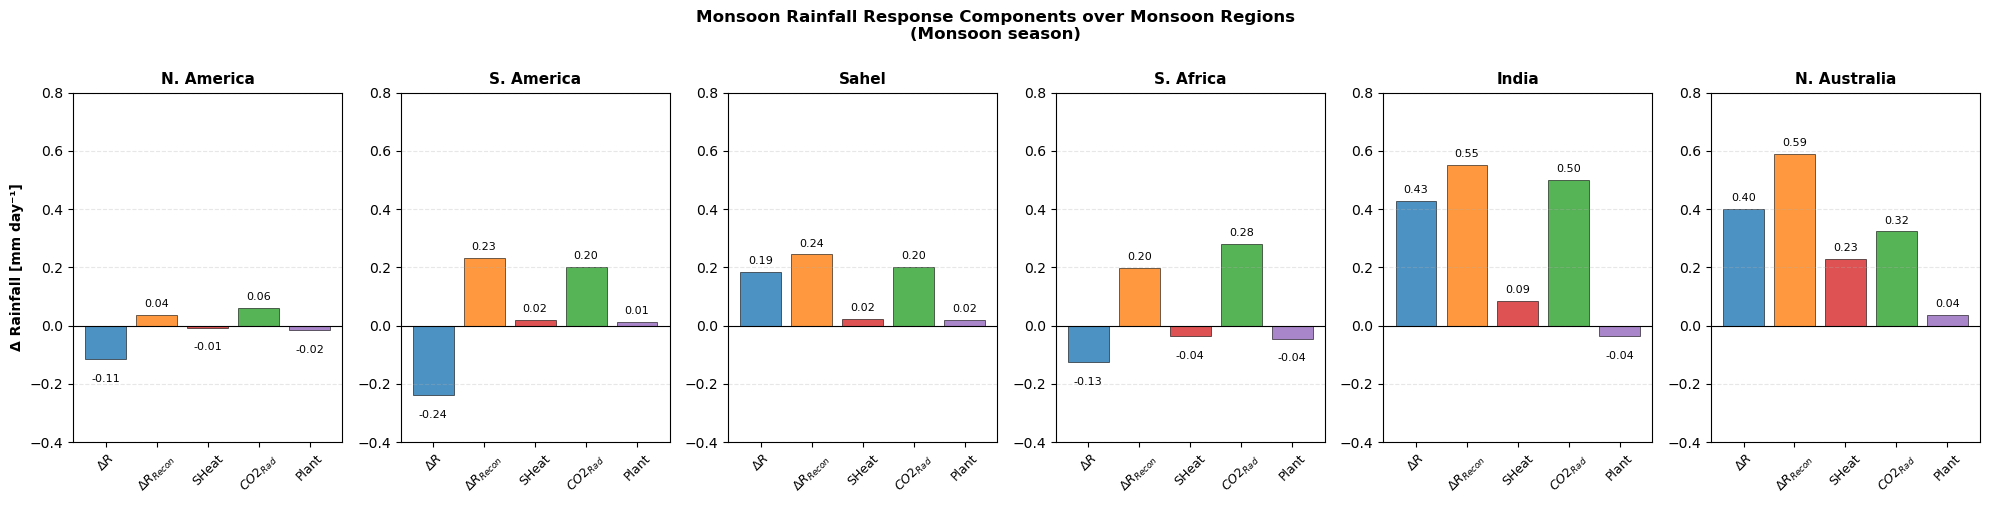

Done!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ================================================================
# LOAD DATA (MONSOON ONLY)
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

print("Loading monsoon rainfall response maps...")
Total_rainfall_response = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_monsoon.nc')
Stratospheric_warming = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_monsoon.nc')
Direct_CO2effect = xr.open_dataarray(f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_monsoon.nc')
Plant_physiology = xr.open_dataarray(f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_monsoon.nc')

# # ================================================================
# # COMPUTE WEIGHTED AVERAGE
# # ================================================================
# # Weights based on Effective Radiative Forcing (ERF)
# CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0  # From Table AIII.4e | ERF time series for SSP5-8.5
# CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0  # From Table AIII.4c | ERF time series for SSP2-4.5
# CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

# print(f'CO2_ERF_SSP585: {CO2_ERF_SSP585:.3f} W/m²')
# print(f'CO2_ERF_SSP245: {CO2_ERF_SSP245:.3f} W/m²')
# print(f'CO2_ERF_SSP585_minus_SSP245: {CO2_ERF_SSP585_minus_SSP245:.3f} W/m²')

# StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
# CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98  # 4CO2 ERF from Knutti et al. 2020
# PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8   # 2CO2 ERF from Knutti et al. 2020

# # Normalize to sum to 1
# weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
# total_weight = sum(weights_unnormalized)
# weights = [w / total_weight for w in weights_unnormalized]

# StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

print(f"\nUnnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight:.6f}")
print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")
print(f"Sum of normalized: {sum(weights):.6f}")

# ================================================================
# MONSOON REGIONS (updated for western hemisphere)
# ================================================================

regions = {
    'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
    'S. America':   {'lon': (-60, -42),    'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),     'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),    'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),     'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),  'lat': (-21,  -9.5)},
}

# ================================================================
# EXTRACT REGIONAL MEANS
# ================================================================

def extract_regional_mean(da, region_coords):
    """Extract spatial mean over a region."""
    lon0, lon1 = region_coords['lon']
    lat0, lat1 = region_coords['lat']
    
    # Handle lon wrapping if needed
    if lon0 < lon1:
        region = da.sel(lon=slice(lon0, lon1), lat=slice(lat0, lat1))
    else:
        # Wrapping case (lon0 > lon1)
        region = da.sel(lon=slice(lon0, 180)) + da.sel(lon=slice(-180, lon1))
    
    return float(region.mean(dim=['lat', 'lon']).values)

# Extract means for all regions
regional_data = {}

for region_name, region_coords in regions.items():
    total = extract_regional_mean(Total_rainfall_response, region_coords)
    strat = StratHeatWeight * extract_regional_mean(Stratospheric_warming, region_coords)
    co2 = CO2effectWeight * extract_regional_mean(Direct_CO2effect, region_coords)
    plant = PlantPhysWeight * extract_regional_mean(Plant_physiology, region_coords)
    reconstructed = strat + co2 + plant
    
    regional_data[region_name] = {
        'total': total,
        'reconstructed': reconstructed,
        'strat': strat,
        'co2': co2,
        'plant': plant,
    }

# ================================================================
# PLOTTING - 1x6 BAR PLOTS (ACTUAL VALUES)
# ================================================================

region_names = list(regions.keys())

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

for region_idx, region_name in enumerate(region_names):
    ax = axes[region_idx]
    
    total = regional_data[region_name]['total']
    reconstructed = regional_data[region_name]['reconstructed']
    strat = regional_data[region_name]['strat']
    co2 = regional_data[region_name]['co2']
    plant = regional_data[region_name]['plant']
    
    # Data for bars - ACTUAL VALUES
    bar_labels = [
        '$\Delta R$',
        '$\Delta R_{Recon}$',
        'SHeat',
        '$CO2_{Rad}$',
        'Plant'
    ]
    values = [
        total,
        reconstructed,
        strat,
        co2,
        plant
    ]
    colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd']
    
    # Create bar plot
    x_pos = np.arange(len(bar_labels))
    bars = ax.bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    ax.set_ylim(-0.4, 0.8)
    
    # Formatting
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bar_labels, fontsize=9, rotation=45)
    if region_idx==0:
        ax.set_ylabel('Δ Rainfall [mm day⁻¹]', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Title with actual values
    # ax.set_title(f'{region_name}\n(Total={total:.2f}, Recon={reconstructed:.2f})', 
    ax.set_title(f'{region_name}', 
                fontsize=11, fontweight='bold')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (0.02 if height > 0 else -0.05),
               f'{value:.2f}',
               ha='center', va='bottom' if height > 0 else 'top', fontsize=8, fontweight='normal')

plt.suptitle('Monsoon Rainfall Response Components over Monsoon Regions\n(Monsoon season)', 
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
# plt.savefig('Monsoon_rainfall_response_1x6_bars.png', dpi=150, bbox_inches="tight")
print("\nFigure saved → Monsoon_rainfall_response_1x6_bars.png")
plt.show()

print("Done!")

# correct from below

Loading monsoon rainfall response maps...
CO2_ERF_SSP585: 7.055 W/m²
CO2_ERF_SSP245: 4.248 W/m²
CO2_ERF_SSP585_minus_SSP245: 2.807 W/m²

Unnormalized weights: [1.0, 0.3518170426065162, 0.7388157894736841]
Sum of unnormalized: 2.090633
Normalized weights: StratHeat=0.478, CO2effect=0.168, PlantPhys=0.353
Sum of normalized: 1.000000

Figure saved → Monsoon_rainfall_response_1x6_percentage_bars.png


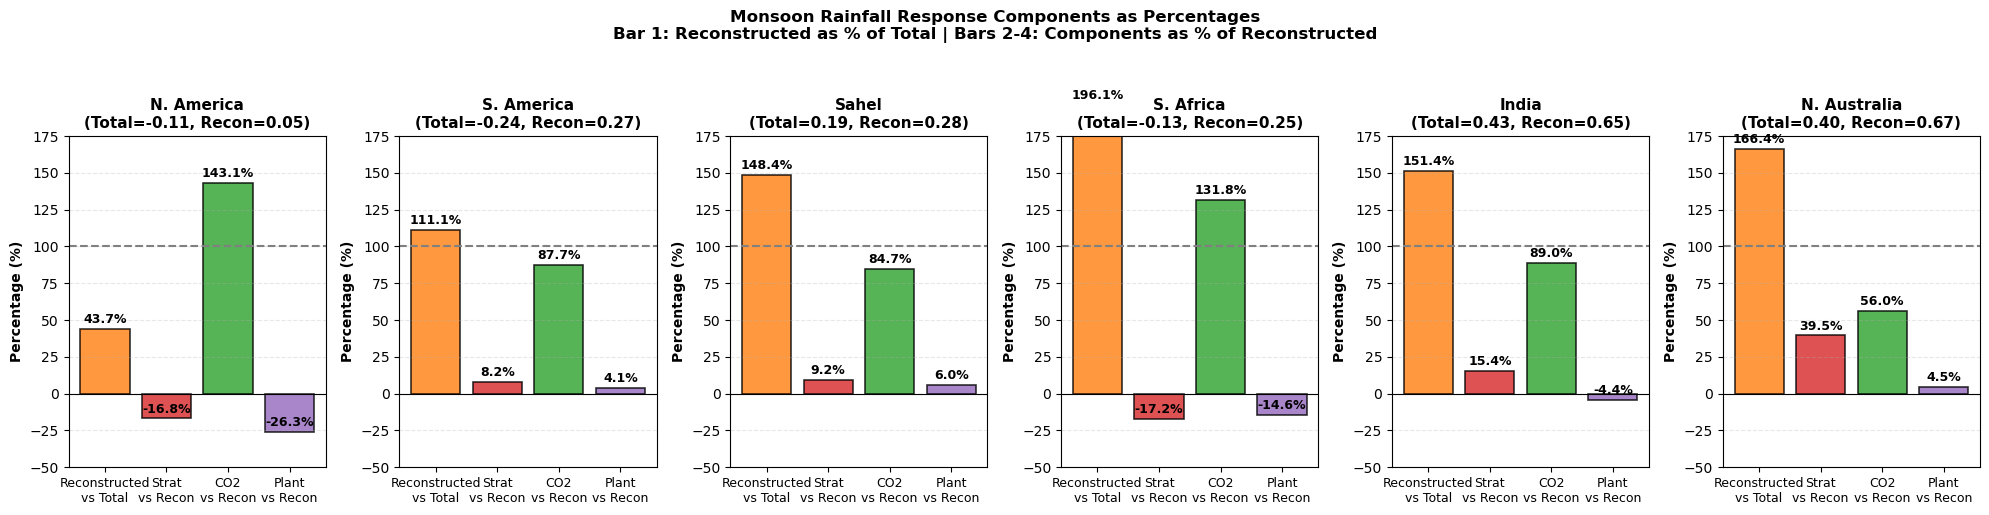

Done!


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ================================================================
# LOAD DATA (MONSOON ONLY)
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

print("Loading monsoon rainfall response maps...")
Total_rainfall_response = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_monsoon.nc')
Stratospheric_warming = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_monsoon.nc')
Direct_CO2effect = xr.open_dataarray(f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_monsoon.nc')
Plant_physiology = xr.open_dataarray(f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_monsoon.nc')

# # ================================================================
# # COMPUTE WEIGHTS
# # ================================================================

# CO2_ERF_SSP585_minus_SSP245 = 1.0  # Placeholder - set to your actual value
# StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
# CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98
# PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8

# # Normalize weights
# weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
# total_weight = sum(weights_unnormalized)
# weights = [w / total_weight for w in weights_unnormalized]

# StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

# print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")

# ================================================================
# COMPUTE WEIGHTED AVERAGE
# ================================================================
# Weights based on Effective Radiative Forcing (ERF)
CO2_ERF_SSP585 = (5.68+6.62+7.54+8.38)/4.0  # From Table AIII.4e | ERF time series for SSP5-8.5
CO2_ERF_SSP245 = (4.01+4.23+4.35+4.40)/4.0  # From Table AIII.4c | ERF time series for SSP2-4.5
CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

print(f'CO2_ERF_SSP585: {CO2_ERF_SSP585:.3f} W/m²')
print(f'CO2_ERF_SSP245: {CO2_ERF_SSP245:.3f} W/m²')
print(f'CO2_ERF_SSP585_minus_SSP245: {CO2_ERF_SSP585_minus_SSP245:.3f} W/m²')

StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98  # 4CO2 ERF from Knutti et al. 2020
PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8   # 2CO2 ERF from Knutti et al. 2020

# Normalize to sum to 1
weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
total_weight = sum(weights_unnormalized)
weights = [w / total_weight for w in weights_unnormalized]

StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

print(f"\nUnnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized: {total_weight:.6f}")
print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")
print(f"Sum of normalized: {sum(weights):.6f}")


# ================================================================
# MONSOON REGIONS (updated for western hemisphere)
# ================================================================

regions = {
    'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
    'S. America':   {'lon': (-60, -42),    'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),     'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),    'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),     'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),  'lat': (-21,  -9.5)},
}

# ================================================================
# EXTRACT REGIONAL MEANS
# ================================================================

def extract_regional_mean(da, region_coords):
    """Extract spatial mean over a region."""
    lon0, lon1 = region_coords['lon']
    lat0, lat1 = region_coords['lat']
    
    # Handle lon wrapping if needed
    if lon0 < lon1:
        region = da.sel(lon=slice(lon0, lon1), lat=slice(lat0, lat1))
    else:
        # Wrapping case (lon0 > lon1)
        region = da.sel(lon=slice(lon0, 180)) + da.sel(lon=slice(-180, lon1))
    
    return float(region.mean(dim=['lat', 'lon']).values)

# Extract means for all regions
regional_data = {}

for region_name, region_coords in regions.items():
    total = extract_regional_mean(Total_rainfall_response, region_coords)
    strat = StratHeatWeight * extract_regional_mean(Stratospheric_warming, region_coords)
    co2 = CO2effectWeight * extract_regional_mean(Direct_CO2effect, region_coords)
    plant = PlantPhysWeight * extract_regional_mean(Plant_physiology, region_coords)
    reconstructed = strat + co2 + plant
    
    regional_data[region_name] = {
        'total': total,
        'reconstructed': reconstructed,
        'strat': strat,
        'co2': co2,
        'plant': plant,
    }

# ================================================================
# PLOTTING - 1x6 BAR PLOTS (PERCENTAGES)
# ================================================================
def safe_percentage(numerator, denominator, use_absolute=False):
    """
    Calculate percentage safely, handling zero and negative values.
    
    Parameters:
    -----------
    numerator : float
        Numerator value
    denominator : float
        Denominator value
    use_absolute : bool
        If True, use absolute values for calculation
        
    Returns:
    --------
    float : percentage value, or 0 if denominator is 0
    """
    if denominator == 0:
        return 0
    
    if use_absolute:
        return (abs(numerator) / abs(denominator) * 100)
    else:
        return (numerator / denominator * 100)


region_names = list(regions.keys())

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Colors for bars
colors_comp = ['#d62728', '#2ca02c', '#9467bd']  # Strat, CO2, Plant

for region_idx, region_name in enumerate(region_names):
    ax = axes[region_idx]
    
    total = regional_data[region_name]['total']
    reconstructed = regional_data[region_name]['reconstructed']
    strat = regional_data[region_name]['strat']
    co2 = regional_data[region_name]['co2']
    plant = regional_data[region_name]['plant']
    
    # Compute percentages
    # # Bar 1: Reconstructed as % of Total
    # recon_pct_of_total = (reconstructed / total * 100) if total != 0 else 0
    # # recon_pct_of_total = ((reconstructed - total ) / total * 100) if total != 0 else 0
    
    # # Bars 2-4: Components as % of Reconstructed
    # strat_pct_of_recon = (strat / reconstructed * 100) if reconstructed != 0 else 0
    # co2_pct_of_recon = (co2 / reconstructed * 100) if reconstructed != 0 else 0
    # plant_pct_of_recon = (plant / reconstructed * 100) if reconstructed != 0 else 0

    # Usage in your code:
    # recon_pct_of_total = safe_percentage(reconstructed, total, use_absolute=True)
    # strat_pct_of_recon = safe_percentage(strat, reconstructed, use_absolute=True)
    # co2_pct_of_recon = safe_percentage(co2, reconstructed, use_absolute=True)
    # plant_pct_of_recon = safe_percentage(plant, reconstructed, use_absolute=True)

    recon_pct_of_total = (reconstructed / abs(total) * 100) if total != 0 else 0
    strat_pct_of_recon = (strat / abs(reconstructed) * 100) if reconstructed != 0 else 0
    co2_pct_of_recon = (co2 / abs(reconstructed) * 100) if reconstructed != 0 else 0
    plant_pct_of_recon = (plant / abs(reconstructed) * 100) if reconstructed != 0 else 0
    
    # Data for bars
    bar_labels = [
        'Reconstructed\nvs Total',
        'Strat\nvs Recon',
        'CO2\nvs Recon',
        'Plant\nvs Recon'
    ]
    values = [
        recon_pct_of_total,
        strat_pct_of_recon,
        co2_pct_of_recon,
        plant_pct_of_recon
    ]
    colors = ['#ff7f0e', '#d62728', '#2ca02c', '#9467bd']
    
    # Create bar plot
    x_pos = np.arange(len(bar_labels))
    bars = ax.bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Add horizontal line at y=100%
    ax.axhline(y=100, color='gray', linewidth=1.5, linestyle='--', label='100%')
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    
    # Formatting
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bar_labels, fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=10, fontweight='bold')
    ax.set_ylim([-50, 175])
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Title with actual values
    ax.set_title(f'{region_name}\n(Total={total:.2f}, Recon={reconstructed:.2f})', 
                fontsize=11, fontweight='bold')
    
    # Add percentage labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
               f'{value:.1f}%',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Monsoon Rainfall Response Components as Percentages\nBar 1: Reconstructed as % of Total | Bars 2-4: Components as % of Reconstructed', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('Monsoon_rainfall_response_1x6_percentage_bars.png', dpi=150, bbox_inches="tight")
print("\nFigure saved → Monsoon_rainfall_response_1x6_percentage_bars.png")
plt.show()

print("Done!")

Loading monsoon rainfall response maps...
Normalized weights: StratHeat=0.720, CO2effect=0.090, PlantPhys=0.190

Figure saved → Monsoon_rainfall_response_1x6_bars.png


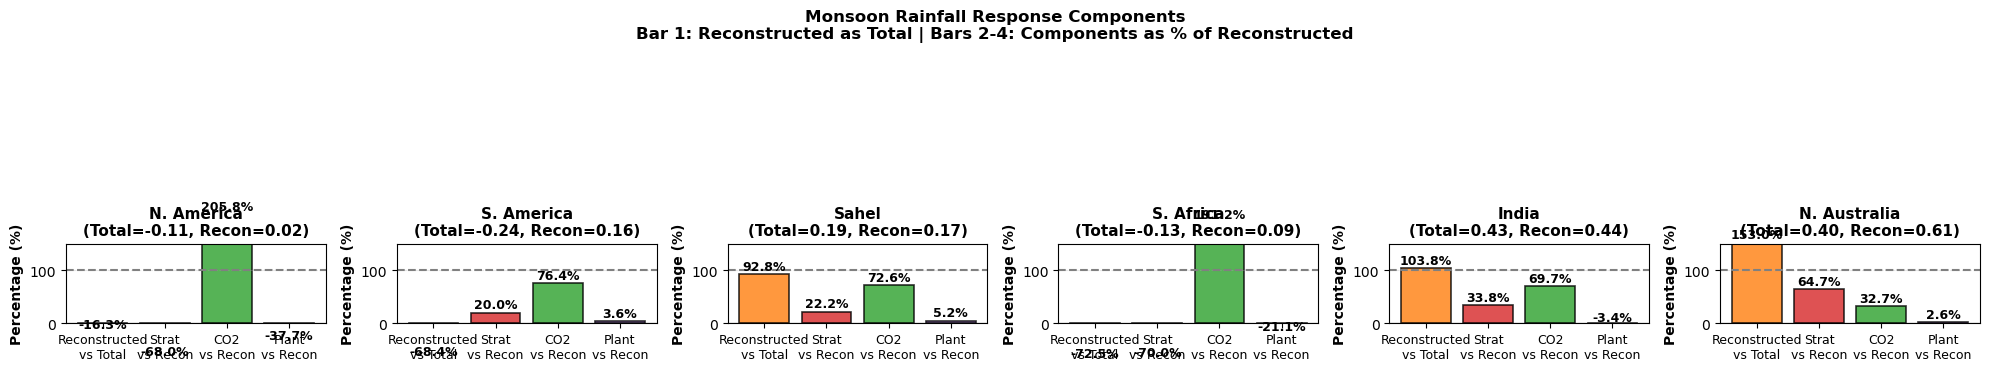

Done!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ================================================================
# LOAD DATA (MONSOON ONLY)
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

print("Loading monsoon rainfall response maps...")
Total_rainfall_response = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_monsoon.nc')
Stratospheric_warming = xr.open_dataarray(f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_monsoon.nc')
Direct_CO2effect = xr.open_dataarray(f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_monsoon.nc')
Plant_physiology = xr.open_dataarray(f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_monsoon.nc')

# ================================================================
# COMPUTE WEIGHTS
# ================================================================

CO2_ERF_SSP585_minus_SSP245 = 1.0  # Placeholder - set to your actual value
StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245
CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98
PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8

# Normalize weights
weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
total_weight = sum(weights_unnormalized)
weights = [w / total_weight for w in weights_unnormalized]

StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

print(f"Normalized weights: StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")

# ================================================================
# MONSOON REGIONS (updated for western hemisphere)
# ================================================================

regions = {
    'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
    'S. America':   {'lon': (-60, -42),    'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),     'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),    'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),     'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),  'lat': (-21,  -9.5)},
}

# ================================================================
# EXTRACT REGIONAL MEANS
# ================================================================

def extract_regional_mean(da, region_coords):
    """Extract spatial mean over a region."""
    lon0, lon1 = region_coords['lon']
    lat0, lat1 = region_coords['lat']
    
    # Handle lon wrapping if needed
    if lon0 < lon1:
        region = da.sel(lon=slice(lon0, lon1), lat=slice(lat0, lat1))
    else:
        # Wrapping case (lon0 > lon1)
        region = da.sel(lon=slice(lon0, 180)) + da.sel(lon=slice(-180, lon1))
    
    return float(region.mean(dim=['lat', 'lon']).values)

# Extract means for all regions
regional_data = {}

for region_name, region_coords in regions.items():
    total = extract_regional_mean(Total_rainfall_response, region_coords)
    strat = StratHeatWeight * extract_regional_mean(Stratospheric_warming, region_coords)
    co2 = CO2effectWeight * extract_regional_mean(Direct_CO2effect, region_coords)
    plant = PlantPhysWeight * extract_regional_mean(Plant_physiology, region_coords)
    reconstructed = strat + co2 + plant
    
    regional_data[region_name] = {
        'total': total,
        'reconstructed': reconstructed,
        'strat': strat,
        'co2': co2,
        'plant': plant,
    }

# ================================================================
# PLOTTING - 1x6 BAR PLOTS (PERCENTAGES)
# ================================================================

region_names = list(regions.keys())

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Colors for bars
colors_comp = ['#d62728', '#2ca02c', '#9467bd']  # Strat, CO2, Plant

for region_idx, region_name in enumerate(region_names):
    ax = axes[region_idx]
    
    total = regional_data[region_name]['total']
    reconstructed = regional_data[region_name]['reconstructed']
    strat = regional_data[region_name]['strat']
    co2 = regional_data[region_name]['co2']
    plant = regional_data[region_name]['plant']
    
    # Compute percentages
    # Bar 1: Reconstructed as % of Total
    recon_pct_of_total = (reconstructed / total * 100) if total != 0 else 0
    
    # Bars 2-4: Components as % of Reconstructed
    strat_pct_of_recon = (strat / reconstructed * 100) if reconstructed != 0 else 0
    co2_pct_of_recon = (co2 / reconstructed * 100) if reconstructed != 0 else 0
    plant_pct_of_recon = (plant / reconstructed * 100) if reconstructed != 0 else 0
    
    # Data for bars
    bar_labels = [
        'Reconstructed\nvs Total',
        'Strat\nvs Recon',
        'CO2\nvs Recon',
        'Plant\nvs Recon'
    ]
    values = [
        recon_pct_of_total,
        strat_pct_of_recon,
        co2_pct_of_recon,
        plant_pct_of_recon
    ]
    colors = ['#ff7f0e', '#d62728', '#2ca02c', '#9467bd']
    
    # Create bar plot
    x_pos = np.arange(len(bar_labels))
    bars = ax.bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Add horizontal line at y=100%
    ax.axhline(y=100, color='gray', linewidth=1.5, linestyle='--', label='100%')
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    
    # Formatting
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bar_labels, fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=10, fontweight='bold')
    ax.set_ylim([0, 150])
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Title with actual values
    ax.set_title(f'{region_name}\n(Total={total:.2f}, Recon={reconstructed:.2f})', 
                fontsize=11, fontweight='bold')
    
    # Add percentage labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
               f'{value:.1f}%',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Monsoon Rainfall Response Components\nBar 1: Reconstructed as Total | Bars 2-4: Components as % of Reconstructed', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('Monsoon_rainfall_response_1x6_bars.png', dpi=150, bbox_inches="tight")
print("\nFigure saved → Monsoon_rainfall_response_1x6_bars.png")
plt.show()

print("Done!")

Loading rainfall response maps...
  Total_rainfall_response:         <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  Stratospheric_warming_component: <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  Direct_CO2effect_component:      <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  Plant_physiology_component:      <xarray.DataArray (lat: 25, lon: 144)> Size: 14kB
[3600

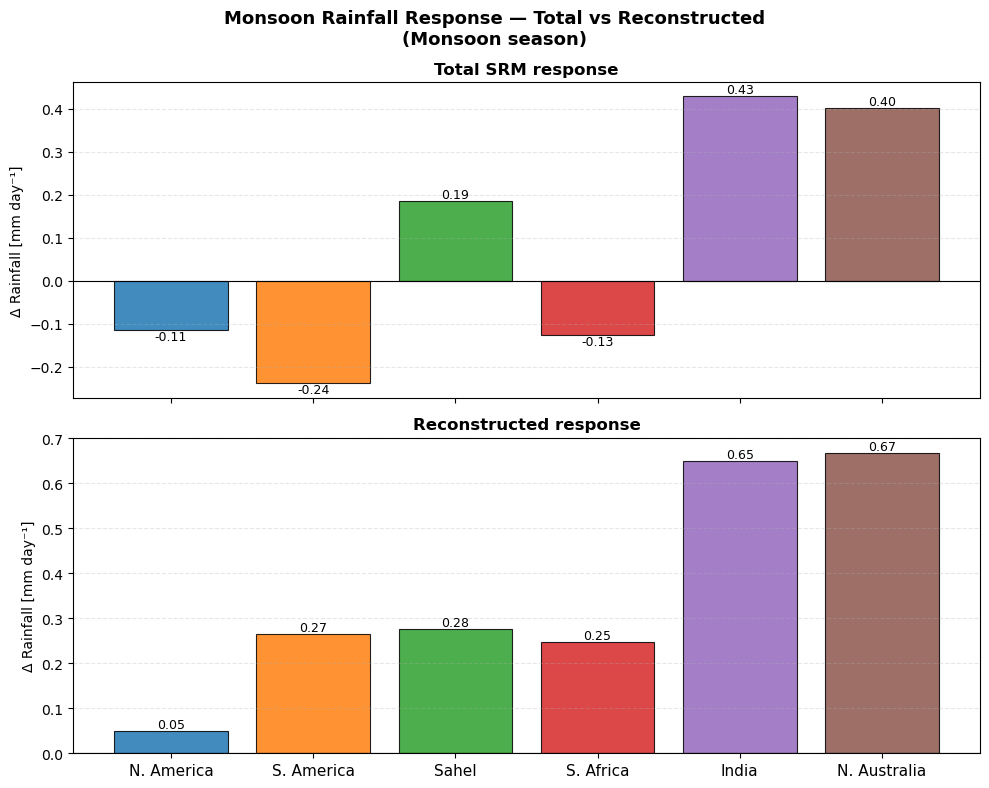

Figure 2 saved → Rainfall_response_monsoon_Plot2_6panels.png


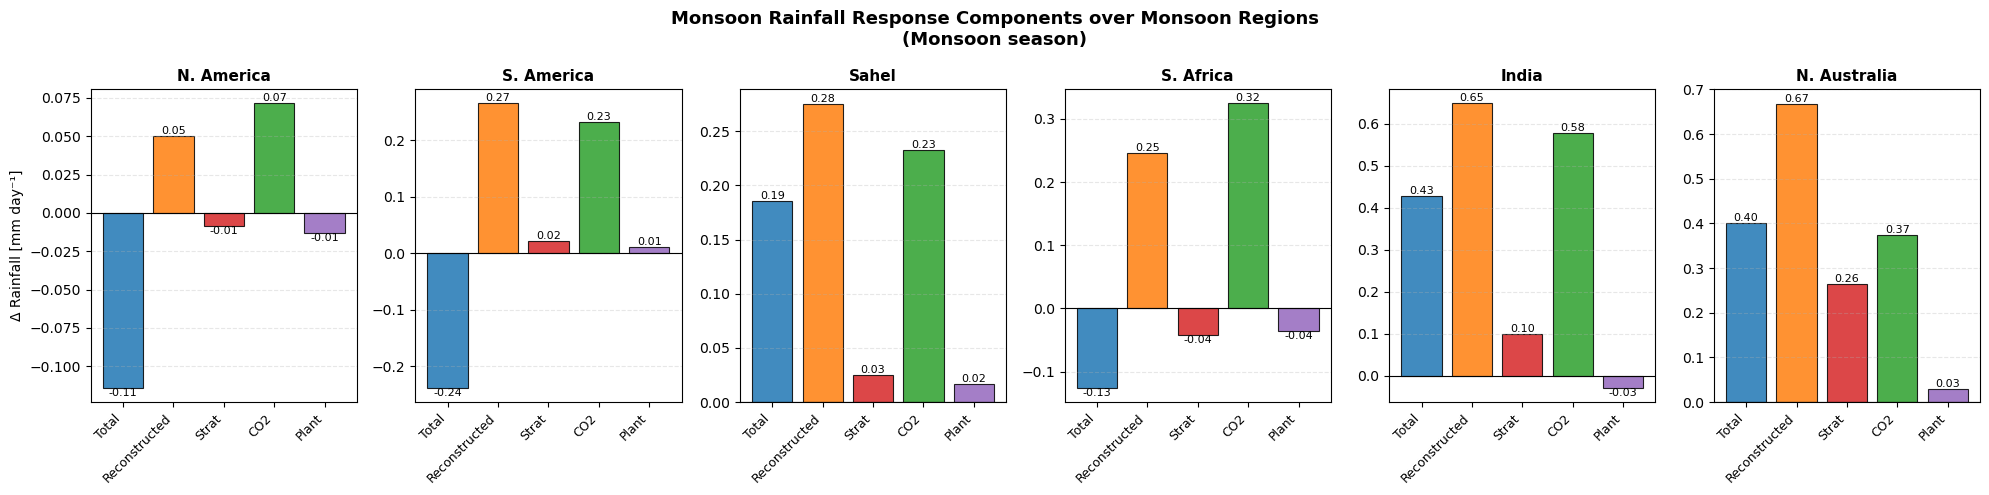

Done!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ================================================================
# LOAD DATA
# ================================================================

data_path = '/gws/ssde/j25b/impose/bidyut/analysis_transient_data'

File_Total_rainfall_response         = f'{data_path}/Rainfall_response_G6sulfur_minus_SSP245_monsoon.nc'
File_Stratospheric_warming_component = f'{data_path}/Rainfall_response_G6sulfur_minus_G6solar_monsoon.nc'
File_Direct_CO2effect_component      = f'{data_path}/Rainfall_response_amip-4xCO2_minus_amip_monsoon.nc'
File_Plant_physiology_component      = f'{data_path}/Rainfall_response_1pctCO2-bgc_minus_piControl_monsoon.nc'

print("Loading rainfall response maps...")
Total_rainfall_response          = xr.open_dataarray(File_Total_rainfall_response)
Stratospheric_warming_component  = xr.open_dataarray(File_Stratospheric_warming_component)
Direct_CO2effect_component       = xr.open_dataarray(File_Direct_CO2effect_component)
Plant_physiology_component       = xr.open_dataarray(File_Plant_physiology_component)

print(f"  Total_rainfall_response:         {Total_rainfall_response}")
print(f"  Stratospheric_warming_component: {Stratospheric_warming_component}")
print(f"  Direct_CO2effect_component:      {Direct_CO2effect_component}")
print(f"  Plant_physiology_component:      {Plant_physiology_component}")

# ================================================================
# COMPUTE WEIGHTED AVERAGE
# ================================================================
CO2_ERF_SSP585 = (5.68 + 6.62 + 7.54 + 8.38) / 4.0
CO2_ERF_SSP245 = (4.01 + 4.23 + 4.35 + 4.40) / 4.0
CO2_ERF_SSP585_minus_SSP245 = CO2_ERF_SSP585 - CO2_ERF_SSP245

print(f'\nCO2_ERF_SSP585:              {CO2_ERF_SSP585:.3f} W/m²')
print(f'CO2_ERF_SSP245:              {CO2_ERF_SSP245:.3f} W/m²')
print(f'CO2_ERF_SSP585_minus_SSP245: {CO2_ERF_SSP585_minus_SSP245:.3f} W/m²')

StratHeatWeight = CO2_ERF_SSP585_minus_SSP245 / CO2_ERF_SSP585_minus_SSP245  # = 1.0
CO2effectWeight = CO2_ERF_SSP585_minus_SSP245 / 7.98   # 4xCO2 ERF from Knutti et al. 2020
PlantPhysWeight = CO2_ERF_SSP585_minus_SSP245 / 3.8    # 2xCO2 ERF from Knutti et al. 2020

weights_unnormalized = [StratHeatWeight, CO2effectWeight, PlantPhysWeight]
total_weight = sum(weights_unnormalized)
weights = [w / total_weight for w in weights_unnormalized]
StratHeatWeight, CO2effectWeight, PlantPhysWeight = weights

print(f"\nUnnormalized weights: {weights_unnormalized}")
print(f"Sum of unnormalized:  {total_weight:.6f}")
print(f"Normalized weights:   StratHeat={StratHeatWeight:.3f}, CO2effect={CO2effectWeight:.3f}, PlantPhys={PlantPhysWeight:.3f}")
print(f"Sum of normalized:    {sum(weights):.6f}")

# ================================================================
# MONSOON REGIONS (Bombardi and Boos 2021)
# ================================================================

regions = {
    'N. America':   {'lon': (-112, -102), 'lat': (18,    33)},
    'S. America':   {'lon': (-60,  -42),  'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,    40),   'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),   'lat': (-18.5, -7)},
    'India':        {'lon': (73,   87),   'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149), 'lat': (-21,  -9.5)},
}

# ================================================================
# EXTRACT REGIONAL MEANS  (DataArray version — no season dim)
# ================================================================

def extract_regional_mean_da(da, region_coords):
    """Extract spatial mean over a region from a 2-D (lat, lon) DataArray."""
    lon0, lon1 = region_coords['lon']
    lat0, lat1 = region_coords['lat']
    lat0, lat1 = min(lat0, lat1), max(lat0, lat1)   # ensure ascending order

    # Longitude might be stored as –180→180 or 0→360; handle both
    lons = da.lon.values
    if lons.min() >= 0 and lon0 < 0:
        # convert requested range to 0–360
        lon0 = lon0 % 360
        lon1 = lon1 % 360

    if lon0 > lon1:   # wrap-around
        mask = ((da.lon >= lon0) | (da.lon <= lon1)) & \
               ((da.lat >= lat0) & (da.lat <= lat1))
        region = da.where(mask, drop=True)
    else:
        region = da.sel(lon=slice(lon0, lon1), lat=slice(lat0, lat1))

    return float(region.mean(dim=['lat', 'lon']).values)

# Compute regional means and build result dict
regional_data = {}

for region_name, region_coords in regions.items():
    total_val  = extract_regional_mean_da(Total_rainfall_response,         region_coords)
    strat_val  = extract_regional_mean_da(Stratospheric_warming_component, region_coords)
    co2_val    = extract_regional_mean_da(Direct_CO2effect_component,      region_coords)
    plant_val  = extract_regional_mean_da(Plant_physiology_component,      region_coords)

    strat_w  = StratHeatWeight * strat_val
    co2_w    = CO2effectWeight  * co2_val
    plant_w  = PlantPhysWeight  * plant_val
    recon    = strat_w + co2_w + plant_w

    regional_data[region_name] = {
        'Total':       total_val,
        'Reconstructed': recon,
        'Strat':       strat_w,
        'CO2':         co2_w,
        'Plant':       plant_w,
    }
    print(f"{region_name:12s}  Total={total_val:.3f}  Recon={recon:.3f}  "
          f"Strat={strat_w:.3f}  CO2={co2_w:.3f}  Plant={plant_w:.3f}")

region_names = list(regions.keys())

# ================================================================
# PLOT 1 — 2 panels: Total (top) and Reconstructed (bottom)
# ================================================================

bar_colors_6 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

fig1, axes1 = plt.subplots(2, 1, figsize=(10, 8))

for row_idx, key in enumerate(['Total', 'Reconstructed']):
    ax = axes1[row_idx]
    vals = [regional_data[r][key] for r in region_names]
    x = np.arange(len(region_names))
    bars = ax.bar(x, vals, color=bar_colors_6, alpha=0.85, edgecolor='black', linewidth=0.8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(region_names if row_idx == 1 else [''] * len(region_names),
                       fontsize=11)
    ax.set_ylabel('Δ Rainfall [mm day⁻¹]', fontsize=10)
    ax.set_title(f'{"Total SRM response" if key=="Total" else "Reconstructed response"}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2., v,
                f'{v:.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=9)

fig1.suptitle('Monsoon Rainfall Response — Total vs Reconstructed\n(Monsoon season)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('Rainfall_response_monsoon_Plot1_2panels.png', dpi=150, bbox_inches='tight')
print("\nFigure 1 saved → Rainfall_response_monsoon_Plot1_2panels.png")
plt.show()

# ================================================================
# PLOT 2 — 6 panels: one per region, bars = Total/Recon/Strat/CO2/Plant
# ================================================================

bar_labels = ['Total', 'Reconstructed', 'Strat', 'CO2', 'Plant']
bar_colors  = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd']

fig2, axes2 = plt.subplots(1, 6, figsize=(20, 5), sharey=False)

for idx, region_name in enumerate(region_names):
    ax = axes2[idx]
    vals = [regional_data[region_name][k]
            for k in ['Total', 'Reconstructed', 'Strat', 'CO2', 'Plant']]

    x = np.arange(len(bar_labels))
    bars = ax.bar(x, vals, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(region_name, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

    if idx == 0:
        ax.set_ylabel('Δ Rainfall [mm day⁻¹]', fontsize=10)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2., v,
                f'{v:.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8)

fig2.suptitle('Monsoon Rainfall Response Components over Monsoon Regions\n(Monsoon season)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('Rainfall_response_monsoon_Plot2_6panels.png', dpi=150, bbox_inches='tight')
print("Figure 2 saved → Rainfall_response_monsoon_Plot2_6panels.png")
plt.show()

print("Done!")